In [2]:
req.libs <- c("data.table", "dplyr", "ggplot2", "scattermore", 
              "stringi", "tidyr", "viridis", "Matrix", "tibble", "ComplexHeatmap", "circlize", "BuenColors")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
[1] "data.table" "stats"      "graphics"   "grDevices"  "utils"     
[6] "datasets"   "methods"    "base"      

[[2]]
[1] "dplyr"      "data.table" "stats"      "graphics"   "grDevices" 
[6] "utils"      "datasets"   "methods"    "base"      

[[3]]
 [1] "ggplot2"    "dplyr"      "data.table" "stats"      "graphics"  
 [6] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[4]]
 [1] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
 [6] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[11] "base"       

[[5]]
 [1] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
 [6] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[11] "methods"     "base"       

[[6]]
 [1] "tidyr"       "stringi"     "scattermore" "ggplot2"     "dplyr"      
 [6] "data.table"  "stats"       "graphics"    "grDevices"   "utils"      
[11] "datasets"    "methods"     "base"       

[[7]]
 [1] "viridis"     "viridisLite" "tidyr"       "stringi"     "scattermore"
 [6] "ggplot2"     "dplyr"       "data.table"  "stats"       "graphics"   
[11] "grDevices"   "utils"       "datasets"    "methods"     "base"       

[[8]]
 [1] "Matrix"      "viridis"     "viridisLite" "tidyr"       "stringi"    
 [6] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
[11] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[16] "base"       

[[9]]
 [1] "tibble"      "Matrix"      "viridis"     "viridisLite" "tidyr"      
 [6] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
[11] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[16] "methods"     "base"       

[[10]]
 [1] "ComplexHeatmap" "grid"           "tibble"         "Matrix"        
 [5] "viridis"        "viridisLite"    "tidyr"          "stringi"       
 [9] "scattermore"    "ggplot2"        "dplyr"          "data.table"    
[13] "stats"          "graphics"       "grDevices"      "utils"         
[17] "datasets"       "methods"        "base"          

[[11]]
 [1] "circlize"       "ComplexHeatmap" "grid"           "tibble"        
 [5] "Matrix"         "viridis"        "viridisLite"    "tidyr"         
 [9] "stringi"        "scattermore"    "ggplot2"        "dplyr"         
[13] "data.table"     "stats"          "graphics"       "grDevices"     
[17] "utils"          "datasets"       "methods"        "base"          

[[12]]
 [1] "BuenColors"     "MASS"           "circlize"       "ComplexHeatmap"
 [5] "grid"           "tibble"         "Matrix"         "viridis"       
 [9] "viridisLite"    "tidyr"          "stringi"        "scattermore"   
[13] "ggplot2"        "dplyr"          "data.table"     "stats"         
[17] "graphics"       "grDevices"      "utils"          "datasets"      
[21] "methods"        "base"

In [3]:
meta <- fread("/mnt/users/rachelsavage/paper_minimorf/data/initial_filtering/atac.filtered.metadata.tsv")
bam.dir <- "/fab/AlignedData/rsav_minimorf/ruochi_temp_barcode_align"
bam.inputs <- list.files(bam.dir, full.names = TRUE, pattern = ".bam$",)

In [62]:
sublib.key <- data.frame(
    buen = c(245:256, 318:342),
    pkr = c(608:644)
)
sublib.key$buen<- paste0("BUENSS", sublib.key$buen)
sublib.key$pkr<- paste0("SS-PKR-", sublib.key$pkr)
#no BUNESS336 aka , SS-PKR-638

sublib.key <- sublib.key %>% filter(pkr != "SS-PKR-638")


In [56]:
## parameters
process.tfs <- function(x){

    n.alignment.cutoff <- 1.5
    alignment.score.cutoff <- 80
    read.support.umi.cutoff <- 2
    
    buenname <- sublib.key$buen[[x]]
    #x
    bam_file <- grep(buenname, bam.inputs, value = TRUE)
    cmd <- sprintf("samtools view -F 256 %s | awk '{print $1, $2, $3, $4, $5, $12, $13, $16, $18}'", bam_file)
    df <- data.table::fread(cmd = cmd, header = FALSE, stringsAsFactors = FALSE)
    setnames(df, c("Read_Name", "Strand", "Alignment", "Alignment_Position", "MAPQ", "Cellbc", "UMI", "n.alignments", "alignment.score"))
    df[, `:=`(
      n.alignments = as.numeric(sub("^NH:i:", "", n.alignments)),
      alignment.score = as.numeric(sub("^AS:i:", "", alignment.score)),
      UMI = sub("^UR:Z:", "", UMI)
    )]
    df <- df[n.alignments <= n.alignment.cutoff & alignment.score > alignment.score.cutoff, 
             .(Alignment, Cellbc, UMI)]
    
    
    # Collapse PCR duplicates
    df <- df[, .(PCR_Dups = .N), 
                       by = .(Alignment, Cellbc, UMI)]
    df[, Cellbc := gsub("_", "", sub("^CR:Z:", "", Cellbc))]
    meta.filt <- meta[sublibrary == sublib.key$pkr[[x]]]
    meta.filt[, Cellbc := tstrsplit(barcode, "_", keep = 1)]
    df <- df[Cellbc %in% meta.filt$Cellbc]
    df <- df[UMI != "GGGGGGGGGG"]
    df <- df[PCR_Dups > read.support.umi.cutoff, 
                         .(n.UMIs = uniqueN(UMI),
                           n.pcr.reads = sum(PCR_Dups)), 
                         by = .(Alignment, Cellbc)]
    #hypergeometric
    background.distribution <- df[, .(
      n.UMIs.total = sum(n.UMIs),
      n.PCR.total = sum(n.pcr.reads)
    ), by = Alignment]
    total.umis <- sum(background.distribution$n.UMIs.total)
    total.pcrs <- sum(background.distribution$n.PCR.total)
    background.distribution[, `:=`(
      non.tf.umis = total.umis - n.UMIs.total,
      non.tf.pcr  = total.pcrs - n.PCR.total
    )]
    df <- merge(df, background.distribution, by = "Alignment")
    df[, `:=`(
      n.umi.cell = sum(n.UMIs),
      n.pcr.cell = sum(n.pcr.reads)
    ), by = Cellbc]
    
    df[, `:=`(
      hyperp.umis = phyper(n.UMIs - 1, m = n.UMIs.total, n = non.tf.umis, k = n.umi.cell, lower.tail = FALSE),
      hyperp.pcr  = phyper(n.pcr.reads - 1, m = n.PCR.total, n = non.tf.pcr, k = n.pcr.cell, lower.tail = FALSE)
    )]
    
    df[, `:=`(
      hyperp.umis.adj = p.adjust(hyperp.umis, method = "BH"),
      hyperp.pcr.adj  = p.adjust(hyperp.pcr, method = "BH")
    )]
    
    df$sublibrary <- sublib.key$pkr[[x]]
    
    return(df)
}


In [4]:
#all.tfs<-lapply(1:nrow(sublib.key), process.tfs)
#saveRDS(all.tfs, "/mnt/users/rachelsavage/paper_minimorf/data/barcode_calling/tf_calls/tfdfs.rds")
all.tfs <- readRDS("/mnt/users/rachelsavage/paper_minimorf/data/barcode_calling/tf_calls/tfdfs.rds")

In [5]:
all.tfs <- do.call(rbind, all.tfs)
all.tfs$Cellbc <- paste0(all.tfs$Cellbc, "_", all.tfs$sublibrary)

Joining with `by = join_by(sublibrary)`
Joining with `by = join_by(sublibrary)`


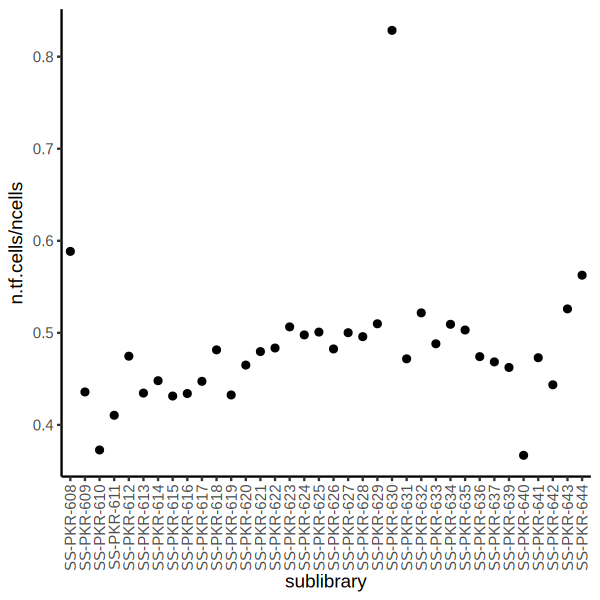

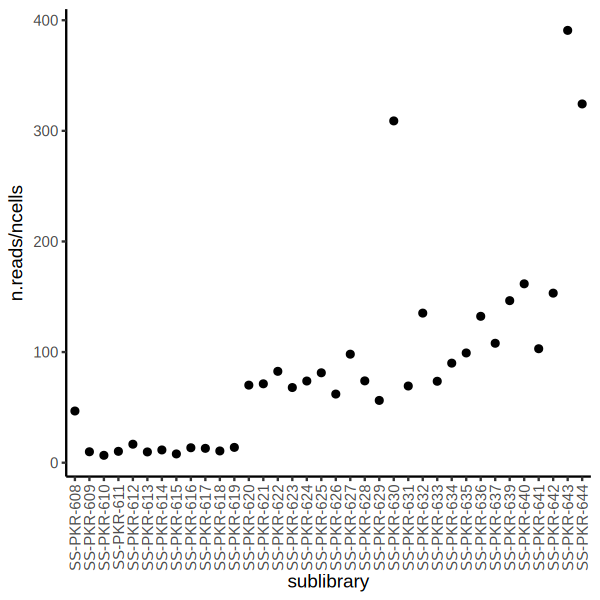

In [6]:
options(repr.plot.width = 5, repr.plot.height = 5)

all.tfs.filt <- all.tfs %>% filter(hyperp.umis.adj < 0.05) 
#dim(all.tfs.filt)
#length(unique(all.tfs.filt$Cellbc))

df1<-all.tfs.filt %>% group_by(sublibrary) %>% summarize(n.tf.cells = length(unique(Cellbc)),
                                                        n.reads = sum(n.pcr.reads),
                                                        n.umis = sum(n.UMIs))
df2<-meta %>% group_by(sublibrary) %>% summarize(ncells = length(unique(barcode)))

df2 %>% left_join(df1) %>%
arrange(n.tf.cells/ncells)%>%
arrange(sublibrary)%>%
mutate(sublibrary = factor(sublibrary, levels = sublibrary))%>%
ggplot(aes(x=sublibrary, y= n.tf.cells/ncells))+
geom_point()+
theme_classic()+theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

df2 %>% left_join(df1) %>%
arrange(n.tf.cells/ncells)%>%
arrange(sublibrary)%>%
mutate(sublibrary = factor(sublibrary, levels = sublibrary))%>%
ggplot(aes(x=sublibrary, y= n.reads/ncells))+
geom_point()+
theme_classic()+theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))


In [7]:
asdf <- all.tfs %>% filter(hyperp.umis.adj < 0.05) %>% group_by(Cellbc) %>% mutate(n.tfs = length(unique(Alignment))) %>% filter(n.tfs<=2) 
length(unique(asdf$Cellbc))
asdf <- all.tfs %>% filter(hyperp.umis.adj < 0.05&hyperp.pcr.adj <0.05) %>% group_by(Cellbc) %>% mutate(n.tfs = length(unique(Alignment))) %>% filter(n.tfs<=2) 
length(unique(asdf$Cellbc))


[1] 354731

[1] 354285

In [8]:
alignment.rename <- data.frame(Alignment = unique(all.tfs$Alignment)) %>%
mutate(TFname = stri_split_fixed(Alignment, pattern = "_", simplify = TRUE)[,1]) %>%
group_by(TFname)%>%
arrange(Alignment)%>%
mutate(isoform = row_number())%>% 
mutate(TFname = ifelse(isoform ==1, TFname, paste0(TFname, "_2"))) %>% dplyr::select(-isoform)

In [9]:
filtered.tf <- all.tfs %>% 
filter(hyperp.umis.adj < 0.05&hyperp.pcr.adj <0.05) %>% 
group_by(Cellbc) %>%
mutate(n.tfs = length(unique(Alignment))) %>%
filter(n.tfs<3)%>%
left_join(alignment.rename) %>%
group_by(Cellbc)%>%
arrange(TFname)%>%
mutate(tf_number = paste0("TF_", row_number())) %>% 
ungroup()%>%
dplyr::select(Cellbc,n.tfs, TFname, tf_number,hyperp.umis.adj, hyperp.pcr.adj,Alignment)%>% 
pivot_wider(names_from = tf_number,values_from=c(TFname,Alignment,hyperp.umis.adj, hyperp.pcr.adj))

colnames(filtered.tf) <- c("barcode", "n.tfs", "TF1", "TF2", "Alignment_TF1", "Alignment_TF2", "padj_umi_TF1", "padj_umi_TF2", "padj_pcr_TF1", "padj_pcr_TF2")
filtered.tf <- filtered.tf %>%
mutate(final.tf = ifelse(n.tfs == 1, TF1, paste(TF1, TF2, sep = "+")))

Joining with `by = join_by(Alignment)`


In [10]:
head(filtered.tf)

barcode,n.tfs,TF1,TF2,Alignment_TF1,Alignment_TF2,padj_umi_TF1,padj_umi_TF2,padj_pcr_TF1,padj_pcr_TF2,final.tf
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TAAGTTCGTCTCGGTTTGTATGCG_SS-PKR-608,2,ASCL2,DBX2,ASCL2_TFORF3108_NM_005170.2,DBX2_TFORF0789_NM_001004329,4.669069e-11,3.113941e-04,2.237332e-249,2.041655e-35,ASCL2+DBX2
GTTAGCCTTGTACCTTGAATCTGT_SS-PKR-608,2,ASCL2,NEUROG3,ASCL2_TFORF3108_NM_005170.2,NEUROG3_TFORF3018_NM_020999.3,1.010898e-11,2.137540e-09,9.712043e-255,2.510661e-177,ASCL2+NEUROG3
GTCTTGGCTGACAGACTTGGAGGT_SS-PKR-608,2,ASCL2,FLI1,ASCL2_TFORF3108_NM_005170.2,FLI1_TFORF2078_NM_001271012,1.659508e-06,3.865615e-02,0.000000e+00,3.381937e-13,ASCL2+FLI1
TCTCGGTTTTGGAGGTTAGTCTTG_SS-PKR-608,1,ASCL2,NA,ASCL2_TFORF3108_NM_005170.2,NA,3.654883e-04,NA,3.580040e-207,NA,ASCL2
TGTGGTTGTGATACGTTGTCTATC_SS-PKR-608,1,ASCL2,NA,ASCL2_TFORF3108_NM_005170.2,NA,1.633606e-03,NA,9.596239e-44,NA,ASCL2
GTTGTCGGTACCACCATCTCTTCA_SS-PKR-608,2,ASCL2,POU2F3,ASCL2_TFORF3108_NM_005170.2,POU2F3_TFORF2206_NM_014352,5.862826e-14,2.317797e-03,0.000000e+00,4.783610e-40,ASCL2+POU2F3


In [11]:
input.mx <- filtered.tf %>%
dplyr::select(barcode, padj_pcr_TF1, padj_pcr_TF2)%>%
pivot_longer(!barcode,values_to = "padj_pcr"
) %>%
mutate(name = gsub("padj_pcr_", "", name))
input.mx2 <- filtered.tf %>%
dplyr::select(barcode, TF1, TF2)%>%
pivot_longer(!barcode
)
input.mx <- input.mx %>% left_join(input.mx2, by = c("barcode", "name")) %>%
mutate(logp = -log10((padj_pcr)))%>%
dplyr::select(barcode, value, logp) %>%
pivot_wider(names_from = value, values_from = logp, values_fill = 0) %>%
column_to_rownames("barcode")%>% as.matrix()
input.mx <- input.mx[, colnames(input.mx) != "NA"]


In [12]:
col.df <- data.frame(TF = colnames(input.mx)) %>% arrange(TF)
rownames(col.df) <- NULL

input.mx <- input.mx[,col.df$TF]


row.df <- data.frame(cellbc = rownames(input.mx),
                     n.tf = rowSums(input.mx > 1.3),
                    top.tf = colnames(input.mx)[max.col(input.mx, ties.method = "first")],
                     top.tf.val = apply(input.mx, 1, max)
)
rownames(row.df) <- NULL
row.df <- row.df %>% filter(n.tf >0)

row.df <- row.df %>%
  #arrange(n.tf, match(top.tf, col.df$TF), -top.tf.val)
  arrange(match(top.tf, col.df$TF), -top.tf.val)

input.mx <- input.mx[row.df$cellbc,]

In [21]:
cutoff<-0.9
topval <- quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff)

labels <- c(1, 0.05, 0.001, 0.0001, 0.00001)

# col_fun<-colorRamp2(c(0, 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], 1-cutoff), 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], 1-cutoff)+0.001, 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff/2), 
#                       quantile(input.mx[input.mx>1.3&!is.infinite(input.mx)], cutoff)), 
#                     c("grey95", "grey90", "rosybrown1", "red", "darkred"))
# cutoff<-0.99
#col_fun<-colorRamp2(c(0, 20,21, 30, 40), c("grey95", "grey90", "rosybrown1", "red", "darkred"))
#col_fun<-colorRamp2(c(0, 20,21, 30, 40), c("grey95", "grey90", "rosybrown1", "red", "darkred"))
#col_fun<-colorRamp2(seq(from = 0, to= topval,length.out = 1000), (jdb_palette("brewer_red", type = "continuous")))
#col_fun<-colorRamp2(c(0, 1.299,1.3, topval/2, topval), c("grey95", "grey90", "tomato", "tomato3", "tomato4"))
col_fun<-colorRamp2(c(0,1.299,1.3, topval), c("grey95", "grey90", "red1", "red4"))


options(repr.plot.width = 14, repr.plot.height = 10)
ht <- Heatmap(input.mx,
       col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
       show_row_names = FALSE,
       show_column_names = TRUE,
       show_row_dend = FALSE,
       show_column_dend = FALSE,
      heatmap_legend_param = list(title = "TF Assignment\n-log10(padj)"),#,
                                 # at = -log10(labels),labels = labels),
        row_title = paste0("Cells (", scales::label_comma()(nrow(input.mx)), ")"),
        column_title = "TFOE",
          use_raster = TRUE,              # rasterize heatmap body
  raster_device = "png",          # raster rendering device
  raster_quality = 2)

In [22]:
#svg("/mnt/users/rachelsavage/paper_minimorf/paper_figures/fig1/fig1.tfpval.svg", width = 10, height = 12)
pdf("/mnt/users/rachelsavage/paper_minimorf/paper_figures/fig1/fig1.tfpval.recolor.pdf", width = 14, height = 10, useDingbats = FALSE)
draw(ht)
dev.off()


agg_record_271189361 
                   2

In [250]:
fwrite(filtered.tf, "/mnt/users/rachelsavage/paper_minimorf/data/barcode_calling/tf_calls/tf.metadata.csv")